# Ensemble Method 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
df = sns.load_dataset( 'titanic')

In [4]:
df.shape

(891, 15)

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.dropna(inplace= True)

In [10]:
df['pclass'].unique()
print(df['pclass'].value_counts())

pclass
1    157
2     15
3     10
Name: count, dtype: int64


In [11]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [12]:
df['sex'].value_counts()

sex
male      94
female    88
Name: count, dtype: int64

<Axes: >

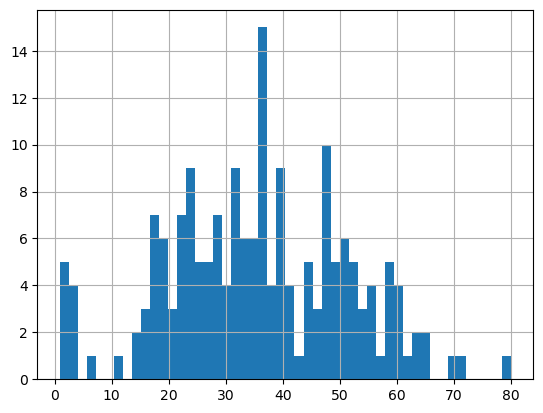

In [17]:
df['age'].hist(bins = 50)

In [20]:
# Data Preprocessing
X = df[['pclass','sex', 'age']].copy()
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()
X['sex'] = le.fit_transform(df['sex'])

In [22]:
X

,pclass,sex,age
1,1,0,38.0
3,1,0,35.0
6,1,1,54.0
10,3,0,4.0
11,1,0,58.0
...,...,...,...
871,1,0,47.0
872,1,1,33.0
879,1,0,56.0
887,1,0,19.0


In [23]:
X.shape

(182, 3)

In [24]:
X.describe()

,pclass,sex,age
count,182.000000,182.000000,182.000000
mean,1.192308,0.516484,35.623187
std,0.516411,0.501107,15.671615
min,1.000000,0.000000,0.920000
25%,1.000000,0.000000,24.000000
50%,1.000000,1.000000,36.000000
75%,1.000000,1.000000,47.750000
max,3.000000,1.000000,80.000000


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  182 non-null    int64  
 1   sex     182 non-null    int32  
 2   age     182 non-null    float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 5.0 KB


In [26]:
y = df['survived'].copy()

In [52]:
y

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: survived, Length: 182, dtype: int64

In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score,roc_auc_score,confusion_matrix
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
base_model =  DecisionTreeClassifier()

In [47]:
BC = BaggingClassifier(base_estimator=base_model,
                       n_estimators= 50,
                       bootstrap= True,
                       random_state=42
                       )
BC.fit(X_train, y_train)


c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

In [48]:
y_prd = BC.predict(X_test)
y_prd

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [49]:
# Accuracy 
accuracy_score(y_prd, y_test)

0.7567567567567568

In [50]:
#Confusion Matrix
confusion_matrix(y_prd, y_test)

array([[ 7,  3],
       [ 6, 21]], dtype=int64)

In [51]:
classification_report(y_prd, y_test)

'              precision    recall  f1-score   support\n\n           0       0.54      0.70      0.61        10\n           1       0.88      0.78      0.82        27\n\n    accuracy                           0.76        37\n   macro avg       0.71      0.74      0.72        37\nweighted avg       0.78      0.76      0.77        37\n'

In [40]:
base_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [42]:
y_prdd = base_model.predict(X_test)
y_prdd

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [43]:
y_prd

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [44]:
# Accuracy 
accuracy_score(y_prdd, y_test)

0.7297297297297297

In [45]:
#Confusion Matrix
confusion_matrix(y_prdd, y_test)

array([[ 7,  4],
       [ 6, 20]], dtype=int64)

In [46]:
classification_report(y_prdd, y_test)

'              precision    recall  f1-score   support\n\n           0       0.54      0.64      0.58        11\n           1       0.83      0.77      0.80        26\n\n    accuracy                           0.73        37\n   macro avg       0.69      0.70      0.69        37\nweighted avg       0.75      0.73      0.74        37\n'

# Using ExtraTreeClassifier

In [83]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier,StackingClassifier
from sklearn.svm import SVC

In [84]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)

# Combine using hard voting (majority)
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('et', et_model)
    ],
    voting='hard'  
)

# Train
voting_model.fit(X_train, y_train)

# Predict
y_pred = voting_model.predict(X_test)

In [85]:
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [86]:
accuracy_score(y_pred, y_test)

0.7297297297297297

In [87]:
voting_model = VotingClassifier(
    estimators=[('rf', rf_model), ('et', et_model)],
    voting='soft'
)


In [88]:

voting_model.fit(X_train, y_train)

# Predict
y_pred = voting_model.predict(X_test)

In [89]:
accuracy_score(y_pred, y_test)

0.7567567567567568

In [94]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)

# Combine using hard voting (majority)
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('et', et_model)
    ],
    final_estimator= SVC()
)

# Train
voting_model.fit(X_train, y_train)

# Predict
y_pred = voting_model.predict(X_test)

In [95]:
y_pred


array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

In [97]:
stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('et', ExtraTreesClassifier(random_state=42))],
                   final_estimator=SVC())

In [98]:
y_pred = stack_model.predict(X_test)

In [99]:
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], dtype=int64)

# Boosting

In [100]:
from sklearn.ensemble import AdaBoostClassifier

In [101]:
base_model = DecisionTreeClassifier(max_depth=1)

In [104]:
AB = AdaBoostClassifier(base_estimator= base_model,
                        n_estimators=50,
                        random_state=45)
AB.fit(X_train, y_train)

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=45)

In [105]:
y_prd = AB.predict(X_test)

In [106]:
y_prd

array([0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1], dtype=int64)